# Low-rank compensation for a split variable

Mini-bucket renormalization replaces an equality constraint between replicas by optimized low-rank compensating factors. After matricization, the local least-squares problem becomes a truncated singular-value decomposition.

In [1]:
CHAPTER_DIR = "ch07"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)
NODE_COLOR = "#34495e"
NODE_TEXT_COLOR = "white"
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## Matricizing a positive local tensor

We create a positive tensor $F(x_a,x_b,x_c,x_d)$ and regard $x_a$ as the split variable. The best rank-one approximation of the corresponding matrix is obtained from the leading singular triplet.

singular values [4.02806324 1.16539624] relative rank-one error 0.2779211935299158


Saved: figs/ch07_03_rank_one_renormalization.pdf


Saved: figs/ch07_03_rank_one_renormalization.png


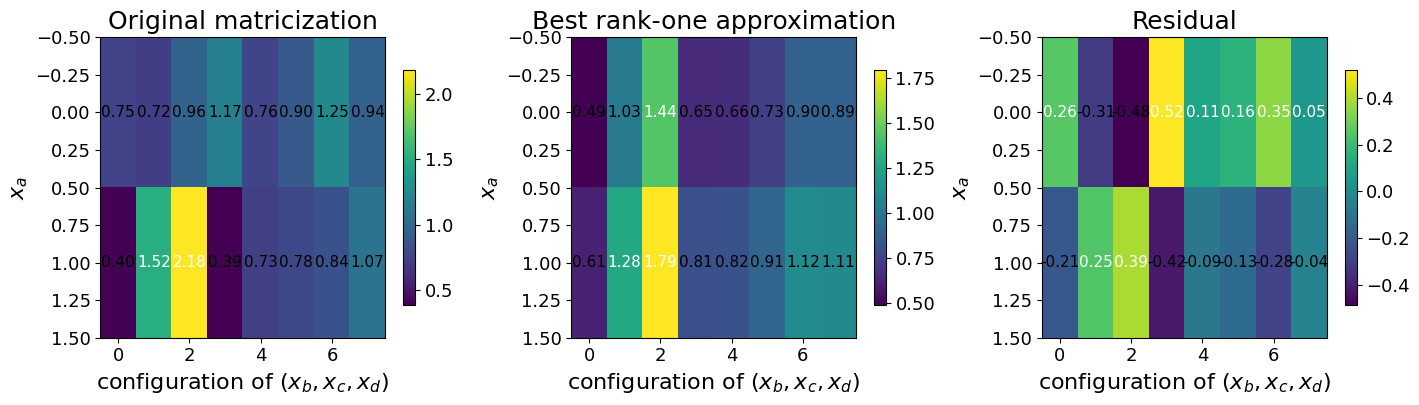

In [2]:
shape=(2,2,2,2)
F=np.exp(RNG.normal(scale=.65,size=shape))
M=F.reshape(2,-1)
U,s,Vt=np.linalg.svd(M,full_matrices=False)
M1=s[0]*np.outer(U[:,0],Vt[0])
rel=np.linalg.norm(M-M1)/np.linalg.norm(M)
print('singular values',s,'relative rank-one error',rel)
fig,axes=plt.subplots(1,3,figsize=(14.5,4.3))
for ax,A,title in zip(axes,[M,M1,M-M1],['Original matricization','Best rank-one approximation','Residual']):
    im=ax.imshow(A,aspect='auto'); ax.set_title(title); ax.set_xlabel('configuration of $(x_b,x_c,x_d)$'); ax.set_ylabel('$x_a$')
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            val=A[i,j]; threshold=(np.nanmin(A)+np.nanmax(A))/2; ax.text(j,i,f'{val:.2f}',ha='center',va='center',color='white' if val>threshold else 'black',fontsize=11)
    fig.colorbar(im,ax=ax,shrink=.78)
fig.tight_layout(); save_figure(fig,'ch07_03_rank_one_renormalization'); plt.show()

## Error versus retained rank

Rank controls the bond dimension of the effective representation. For a binary split variable the full rank is at most two; rank one is the strongest compression.

Saved: figs/ch07_03_error_vs_rank.pdf
Saved: figs/ch07_03_error_vs_rank.png


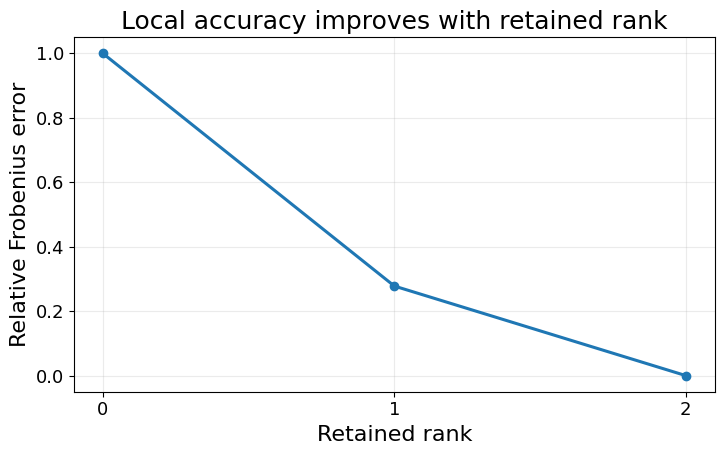

In [3]:
errs=[]
for r in [0,1,2]:
    if r==0: Mr=np.zeros_like(M)
    else: Mr=(U[:,:r]*s[:r])@Vt[:r]
    errs.append(np.linalg.norm(M-Mr)/np.linalg.norm(M))
fig,ax=plt.subplots(figsize=(7.5,4.8)); ax.plot([0,1,2],errs,marker='o',linewidth=2.2); ax.set_xticks([0,1,2]); ax.set_xlabel('Retained rank'); ax.set_ylabel('Relative Frobenius error'); ax.set_title('Local accuracy improves with retained rank'); ax.grid(alpha=.25); fig.tight_layout(); save_figure(fig,'ch07_03_error_vs_rank'); plt.show()

## Stress test: rank-one compression fails when the singular spectrum flattens

A favorable tensor can make rank-one compression look almost exact. To expose the actual limitation, we construct a one-parameter family of positive matrices whose two rows move from proportional to genuinely independent. At the proportional endpoint the matrix is rank one. As the second singular value grows, the best rank-one approximation must discard an increasing fraction of the local dependence.

The singular-value ratio $\sigma_2/\sigma_1$ is therefore both a hardness parameter and a local diagnostic: it tells us when the low-rank assumption itself is breaking down.


Saved: figs/ch07_03_rank_one_stress.pdf
Saved: figs/ch07_03_rank_one_stress.png


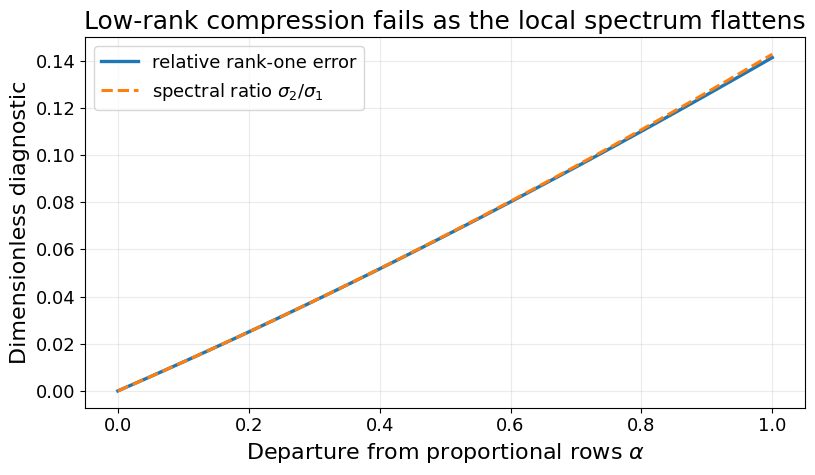

In [4]:
v = np.exp(RNG.normal(scale=0.45, size=8))
w = np.exp(RNG.normal(scale=0.45, size=8))
w *= np.linalg.norm(v) / np.linalg.norm(w)
alpha_grid = np.linspace(0.0, 1.0, 51)
rank1_error = []
spectral_ratio = []
for alpha in alpha_grid:
    M_alpha = np.vstack([v, (1.0 - alpha) * 1.15 * v + alpha * w])
    Ua, sa, Vta = np.linalg.svd(M_alpha, full_matrices=False)
    M_alpha_1 = sa[0] * np.outer(Ua[:, 0], Vta[0])
    rank1_error.append(np.linalg.norm(M_alpha - M_alpha_1) / np.linalg.norm(M_alpha))
    spectral_ratio.append(sa[1] / sa[0])

fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.plot(alpha_grid, rank1_error, linewidth=2.4, label="relative rank-one error")
ax.plot(alpha_grid, spectral_ratio, linewidth=2.2, linestyle="--", label=r"spectral ratio $\sigma_2/\sigma_1$")
ax.set_xlabel(r"Departure from proportional rows $\alpha$")
ax.set_ylabel("Dimensionless diagnostic")
ax.set_title("Low-rank compression fails as the local spectrum flattens")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "ch07_03_rank_one_stress")
plt.show()


## Exercises

1. Repeat for a ternary split variable.
2. Compare the SVD approximation with a nonnegative matrix factorization.
3. Propagate the local approximation through a short elimination sequence and measure the resulting partition-function error.